# How an MLP Solves XOR: Visualizing the Warp to Linear Separability

XOR is the classic problem a single linear classifier **cannot** solve — no straight line
separates the two classes in the input plane. A multilayer perceptron (MLP) solves it by
**warping** the input space: the first linear layer + a nonlinear activation bend the plane so
that the two classes become linearly separable, and the output neuron then draws a simple
straight line through the warped space.

This notebook makes every step of that warp **visible**:
1. XOR in the input plane (and why no line works).
2. Train a tiny 2-2-1 MLP (`tanh` hidden units).
3. The learned decision boundary in input space (curved!).
4. **The warp, step by step:** input grid → after the first *linear* layer → after the
   *activation function* — with the output neuron's straight separating line drawn in the
   final (hidden) space.
5. The activation function itself, and a morph animation of the whole transformation.

In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
%matplotlib inline
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.grid'] = False

C0, C1 = '#2166ac', '#b2182b'      # class 0 (blue), class 1 (red)
CMAP = ListedColormap([C0, C1])
REGION_CMAP = ListedColormap(['#d7e3f0', '#f3d9dc'])   # faint fill for class regions

## 1. The XOR data — no straight line separates it

Four points: opposite corners share a class. Class 1 = `{(0,1),(1,0)}`, class 0 = `{(0,0),(1,1)}`.
Any straight line you draw leaves at least one point misclassified.

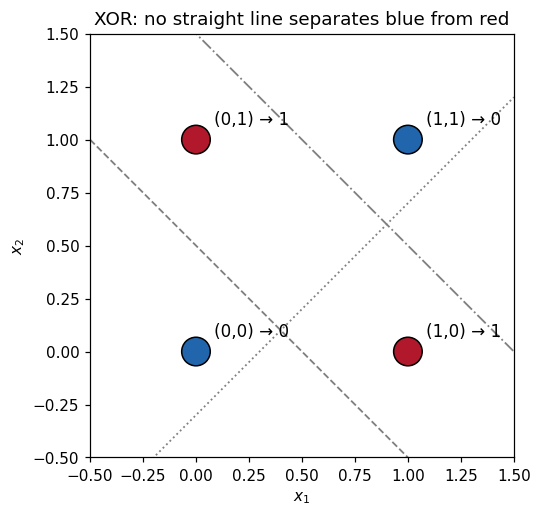

In [2]:
X = torch.tensor([[0.,0.],[0.,1.],[1.,0.],[1.,1.]])
y = torch.tensor([0.,1.,1.,0.])
Xn = X.numpy(); yn = y.numpy()

fig, ax = plt.subplots(figsize=(5,5))
ax.scatter(Xn[:,0], Xn[:,1], c=yn, cmap=CMAP, s=350, edgecolors='k', zorder=3)
for (px,py_),cl in zip(Xn, yn):
    ax.annotate(f'({px:.0f},{py_:.0f}) → {int(cl)}', (px,py_),
                textcoords='offset points', xytext=(12,10), fontsize=11)
# a few candidate lines that all fail
xs = np.linspace(-0.5,1.5,10)
for m,b,ls in [(-1,0.5,'--'),(1,-0.3,':'),(-1,1.5,'-.')]:
    ax.plot(xs, m*xs+b, color='gray', lw=1.2, ls=ls)
ax.set_xlim(-0.5,1.5); ax.set_ylim(-0.5,1.5)
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
ax.set_title('XOR: no straight line separates blue from red')
ax.set_aspect('equal'); plt.tight_layout(); plt.show()

## 2. A tiny MLP: 2 inputs → 2 tanh hidden units → 1 output

Two hidden units is the minimum that can solve XOR, and keeping the hidden layer 2-D lets us
**plot the hidden space directly**. We train with a few random restarts and keep the best solution
(2-unit XOR training occasionally gets stuck in a bad local minimum).

In [3]:
def make_model(seed):
    torch.manual_seed(seed)
    return nn.Sequential(nn.Linear(2,2), nn.Tanh(), nn.Linear(2,1))

def train(model, steps=4000, lr=0.08):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    lossf = nn.BCEWithLogitsLoss()
    hist = []
    for _ in range(steps):
        opt.zero_grad()
        logit = model(X).squeeze(1)
        loss = lossf(logit, y)
        loss.backward(); opt.step()
        hist.append(loss.item())
    return hist

best = None
for seed in range(30):
    m = make_model(seed); h = train(m)
    if best is None or h[-1] < best[1]:
        best = (m, h[-1], h, seed)
model, final_loss, loss_hist, best_seed = best
print(f'best seed={best_seed}  final loss={final_loss:.5f}')
with torch.no_grad():
    preds = (torch.sigmoid(model(X).squeeze(1))>0.5).float()
print('predictions:', preds.tolist(), ' targets:', y.tolist(),
      ' -> solved!' if (preds==y).all() else ' -> NOT solved')

best seed=2  final loss=0.00002
predictions: [0.0, 1.0, 1.0, 0.0]  targets: [0.0, 1.0, 1.0, 0.0]  -> solved!


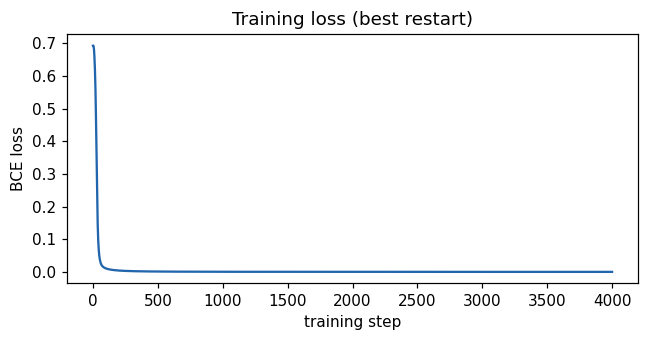

In [4]:
fig, ax = plt.subplots(figsize=(6,3.2))
ax.plot(loss_hist, color='#2166ac')
ax.set_xlabel('training step'); ax.set_ylabel('BCE loss')
ax.set_title('Training loss (best restart)'); plt.tight_layout(); plt.show()

## 3. The decision boundary in input space is *curved*

Evaluate the trained network over a fine grid and shade where it predicts each class. The boundary
is not a straight line — the network has effectively learned a curved separator in the original
input plane.

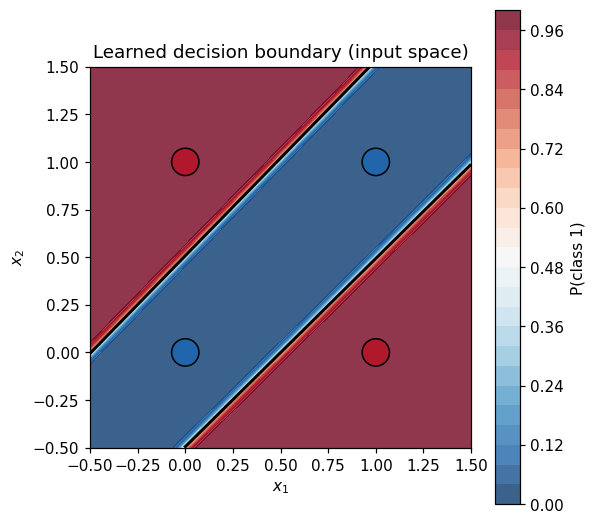

In [5]:
g = np.linspace(-0.5,1.5,300)
gx,gy = np.meshgrid(g,g)
grid = np.stack([gx.ravel(),gy.ravel()],1)
with torch.no_grad():
    prob = torch.sigmoid(model(torch.tensor(grid,dtype=torch.float32)).squeeze(1)).numpy()
P = prob.reshape(gx.shape)

fig, ax = plt.subplots(figsize=(5.5,5))
cf = ax.contourf(gx,gy,P,levels=30,cmap='RdBu_r',alpha=0.8)
ax.contour(gx,gy,P,levels=[0.5],colors='k',linewidths=2)
ax.scatter(Xn[:,0],Xn[:,1],c=yn,cmap=CMAP,s=320,edgecolors='k',zorder=3)
plt.colorbar(cf,ax=ax,label='P(class 1)')
ax.set_xlim(-0.5,1.5); ax.set_ylim(-0.5,1.5); ax.set_aspect('equal')
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
ax.set_title('Learned decision boundary (input space)'); plt.tight_layout(); plt.show()

## 4. The warp, step by step

Here is the heart of it. Take a **grid** covering the input plane and push it through the network
one stage at a time:

1. **Input space** — the original grid.
2. **After the first *linear* layer** ($z = W_1 x + b_1$) — an affine map: the grid is rotated,
   scaled, and skewed, but lines stay straight. Still not separable by a line.
3. **After the *activation function*** ($h = \tanh(z)$) — the nonlinearity **bends** the grid and
   squashes it into $(-1,1)^2$. Now the four points land such that a **single straight line**
   (the output neuron) separates the classes. That line is drawn in the third panel.

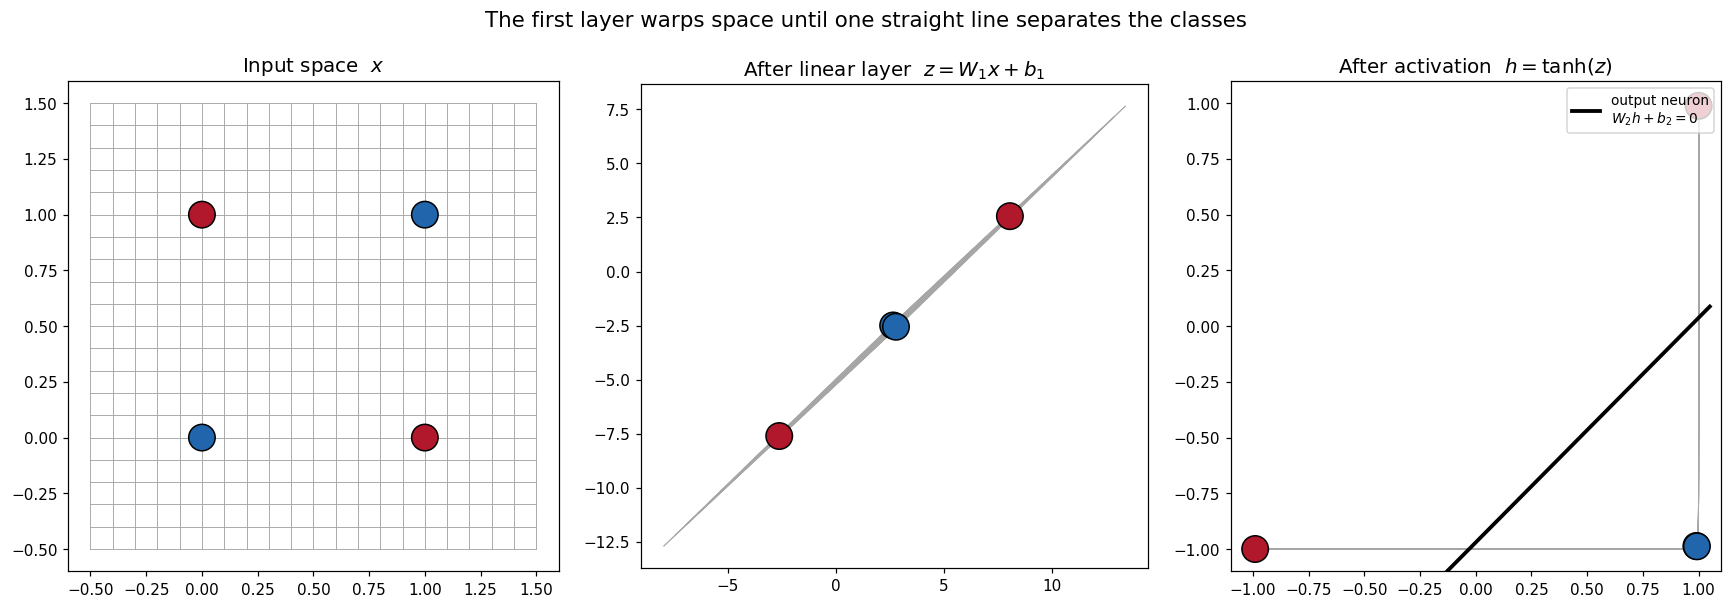

In [6]:
# pull out layer 1 weights and define the two transforms
lin1, act, lin2 = model[0], model[1], model[2]
W1 = lin1.weight.detach().numpy(); b1 = lin1.bias.detach().numpy()
W2 = lin2.weight.detach().numpy().ravel(); b2 = lin2.bias.detach().numpy().item()

def pre_act(pts):  return pts @ W1.T + b1            # z = W1 x + b1
def post_act(pts): return np.tanh(pre_act(pts))      # h = tanh(z)

# a coarse grid whose warping we can see
ng = 21
gg = np.linspace(-0.5,1.5,ng)
mx,my = np.meshgrid(gg,gg)
gridc = np.stack([mx.ravel(),my.ravel()],1)

def draw_grid(ax, pts, n=ng, color='0.65', lw=0.6):
    Pg = pts.reshape(n,n,2)
    for i in range(n):
        ax.plot(Pg[i,:,0],Pg[i,:,1],color=color,lw=lw,zorder=1)
        ax.plot(Pg[:,i,0],Pg[:,i,1],color=color,lw=lw,zorder=1)

stages = [('Input space  $x$', gridc, Xn),
          ('After linear layer  $z=W_1x+b_1$', pre_act(gridc), pre_act(Xn)),
          ('After activation  $h=\\tanh(z)$', post_act(gridc), post_act(Xn))]

fig, axes = plt.subplots(1,3,figsize=(16,5.2))
for ax,(title,gpts,dpts) in zip(axes,stages):
    draw_grid(ax,gpts)
    ax.scatter(dpts[:,0],dpts[:,1],c=yn,cmap=CMAP,s=300,edgecolors='k',zorder=3)
    ax.set_title(title,fontsize=13); ax.set_aspect('equal')
# draw the output neuron's separating line in the hidden (post-activation) panel
axh = axes[2]
h0 = np.linspace(-1.05,1.05,50)
if abs(W2[1])>1e-6:
    h1 = -(W2[0]*h0 + b2)/W2[1]
    axh.plot(h0,h1,'k-',lw=2.5,zorder=2,label='output neuron\n$W_2 h + b_2 = 0$')
    axh.legend(loc='upper right',fontsize=9)
axh.set_xlim(-1.1,1.1); axh.set_ylim(-1.1,1.1)
fig.suptitle('The first layer warps space until one straight line separates the classes',
             fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

### Before vs. after the activation (zoom on the 4 points)

Same four points, left = after the linear layer only, right = after `tanh`. The activation is what
tips them into a linearly separable arrangement.

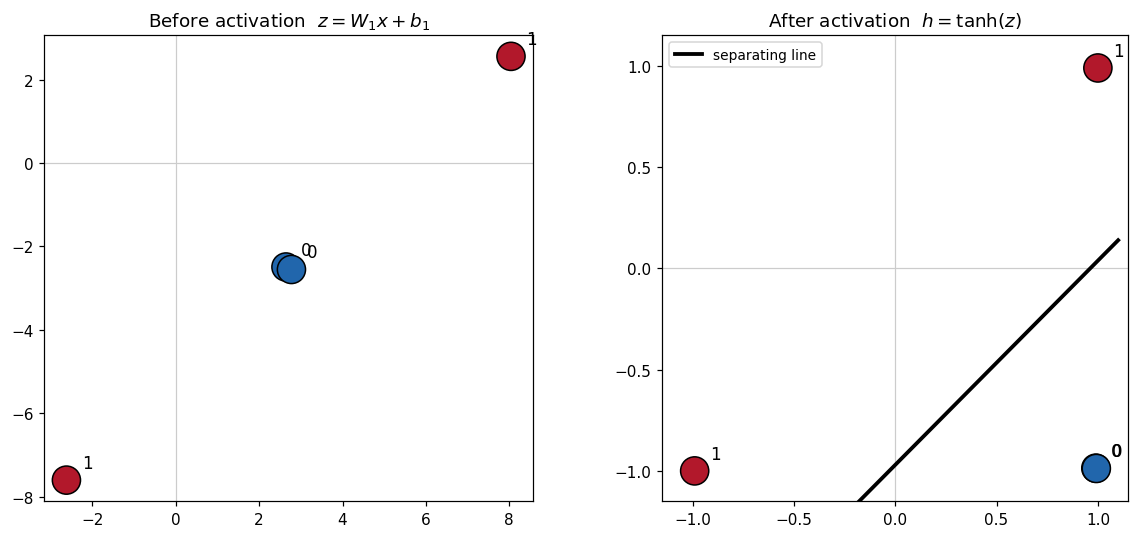

In [7]:
fig, (a1,a2) = plt.subplots(1,2,figsize=(11,5))
z = pre_act(Xn); hh = post_act(Xn)
for ax,pts,title in [(a1,z,'Before activation  $z=W_1x+b_1$'),(a2,hh,'After activation  $h=\\tanh(z)$')]:
    ax.scatter(pts[:,0],pts[:,1],c=yn,cmap=CMAP,s=340,edgecolors='k',zorder=3)
    for p,cl in zip(pts,yn):
        ax.annotate(f'{int(cl)}',(p[0],p[1]),textcoords='offset points',xytext=(10,8),fontsize=11)
    ax.set_title(title); ax.set_aspect('equal'); ax.axhline(0,color='0.8',lw=.8); ax.axvline(0,color='0.8',lw=.8)
h0 = np.linspace(-1.1,1.1,50)
if abs(W2[1])>1e-6:
    a2.plot(h0, -(W2[0]*h0+b2)/W2[1],'k-',lw=2.5,label='separating line'); a2.legend(fontsize=9)
a2.set_xlim(-1.15,1.15); a2.set_ylim(-1.15,1.15)
plt.tight_layout(); plt.show()

## 5. The activation function doing the squashing

`tanh` compresses large pre-activations toward ±1. The dots show where each data point's
pre-activations (for both hidden units) land on the curve — pushing them toward the corners of
the $(-1,1)^2$ hidden square.

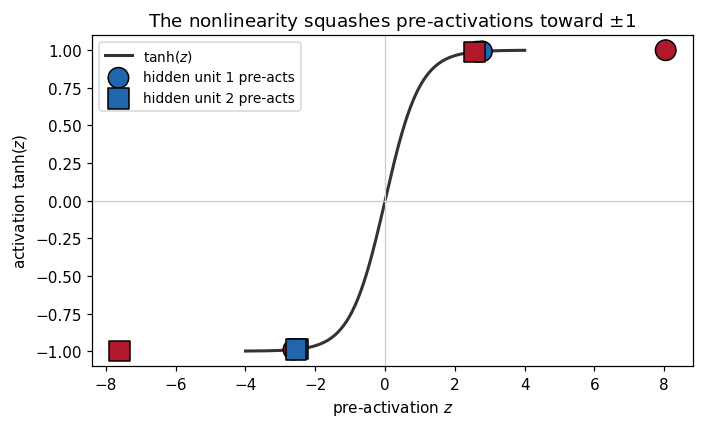

In [8]:
t = np.linspace(-4,4,200)
fig, ax = plt.subplots(figsize=(6.5,4))
ax.plot(t, np.tanh(t), color='#333', lw=2, label=r'$\tanh(z)$')
ax.axhline(0,color='0.8',lw=.8); ax.axvline(0,color='0.8',lw=.8)
z = pre_act(Xn)
for j,mk in enumerate(['o','s']):
    ax.scatter(z[:,j], np.tanh(z[:,j]), c=yn, cmap=CMAP, s=180, edgecolors='k',
               marker=mk, zorder=3, label=f'hidden unit {j+1} pre-acts')
ax.set_xlabel('pre-activation $z$'); ax.set_ylabel('activation $\\tanh(z)$')
ax.set_title('The nonlinearity squashes pre-activations toward $\\pm 1$')
ax.legend(fontsize=9); plt.tight_layout(); plt.show()

## 6. Morphing the whole transformation

Interpolating from the input layout to the post-activation layout shows the plane continuously
bending. Watch the grid go from straight → skewed → curved as the linear map and then the
nonlinearity take effect.

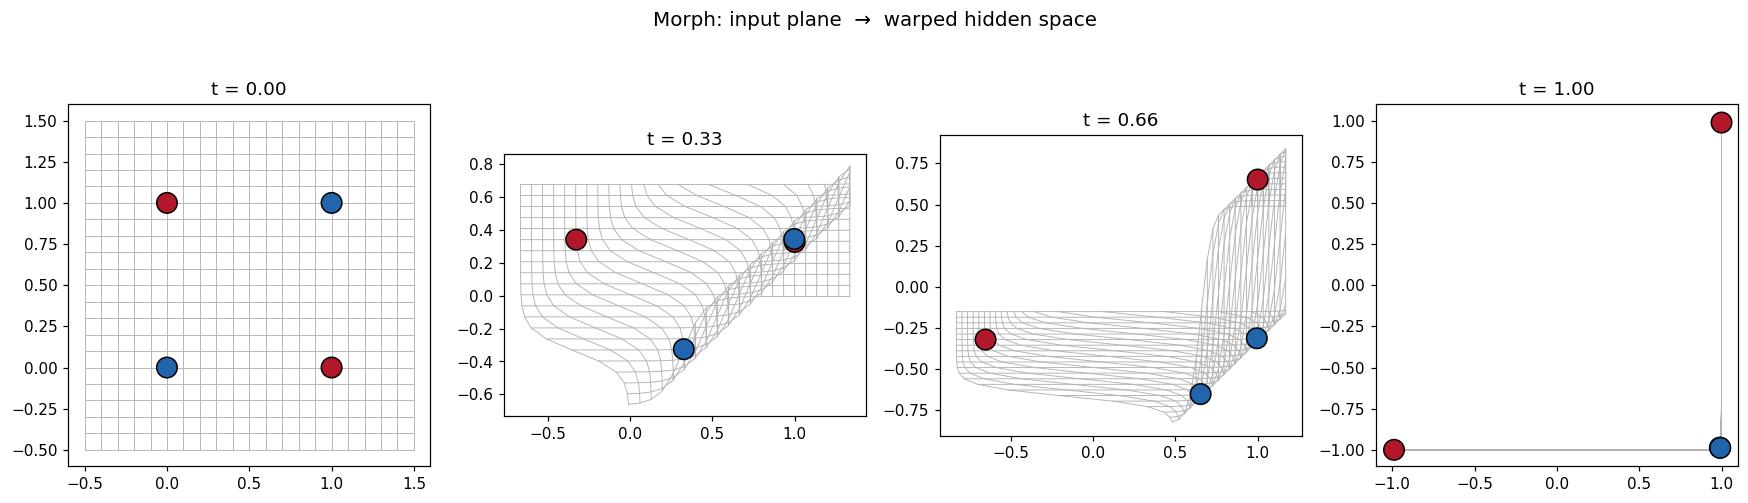

In [9]:
ts = [0.0, 0.33, 0.66, 1.0]
start = gridc
end = post_act(gridc)
startX = Xn; endX = post_act(Xn)
fig, axes = plt.subplots(1,len(ts),figsize=(16,4.4))
for ax,t in zip(axes,ts):
    gp = (1-t)*start + t*end
    dp = (1-t)*startX + t*endX
    draw_grid(ax, gp, color='0.7')
    ax.scatter(dp[:,0],dp[:,1],c=yn,cmap=CMAP,s=180,edgecolors='k',zorder=3)
    ax.set_title(f't = {t:.2f}'); ax.set_aspect('equal')
fig.suptitle('Morph: input plane  →  warped hidden space', y=1.03, fontsize=13)
plt.tight_layout(); plt.show()

## Takeaway

A single linear layer can only draw straight boundaries, so it can never solve XOR. The MLP's
first layer + `tanh` **re-coordinate the plane** — rotating, skewing, then bending it — until the
two classes sit on opposite sides of one straight line. The output neuron draws that line in the
warped (hidden) space; mapped back to the input plane, it becomes the curved decision boundary we
saw in section 3. That is the essence of what depth + nonlinearity buys you: **learned coordinate
systems in which hard problems become linearly separable.**